In [58]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import io, measure
from skimage.segmentation import morphological_geodesic_active_contour,inverse_gaussian_gradient



In [79]:
img=io.imread(r'mri\9606664\images\9606664_07.bmp', as_gray=True)

init_mask=np.zeros(img.shape,dtype=np.int8)

yy,xx=np.ogrid[:img.shape[0],:img.shape[1]]

circle=(yy-240)**2 + (xx-230) **2<= 60**2
init_mask[circle]=1

In [80]:
gimage=inverse_gaussian_gradient(img,alpha=100,sigma=2
)

final_mask=morphological_geodesic_active_contour(gimage,num_iter=130,init_level_set=init_mask,smoothing=2,balloon=0.7)

In [81]:
# =====================================================================
# --- NEW: Connected Component Analysis (Island Filtering) ---
# 1. Label all distinct, disconnected components in the final mask
labeled_mask = measure.label(final_mask)

# 2. Calculate properties (like area) for each labeled component
regions = measure.regionprops(labeled_mask)

# 3. Filter out the noise and keep only the largest component
if regions:
    # Find the region with the largest pixel area
    largest_region = max(regions, key=lambda r: r.area)
    
    # Create a new, clean mask containing ONLY the largest region
    clean_final_mask = (labeled_mask == largest_region.label).astype(np.int8)
else:
    # Fallback in case the mask is entirely empty
    clean_final_mask = final_mask

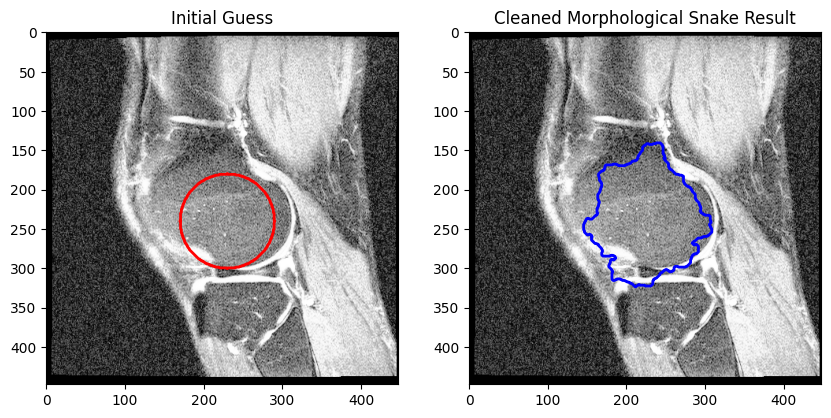

In [82]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap="gray")
ax[0].contour(init_mask, [0.5], colors='r', linewidths=2) # Draw initial mask boundary
ax[0].set_title("Initial Guess")

ax[1].imshow(img, cmap="gray")
ax[1].contour(clean_final_mask, [0.5], colors='b', linewidths=2) # Draw final mask boundary
ax[1].set_title("Cleaned Morphological Snake Result")

plt.show()